# Exploratory Data Analysis
## CW1 - Regression Challenge

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(123)
trn = pd.read_csv('../data/raw/CW1_train.csv')
tst = pd.read_csv('../data/raw/CW1_test.csv')

print(f"Train shape: {trn.shape}")
print(f"Test shape:  {tst.shape}")
print(f"\nColumns: {list(trn.columns)}")

Train shape: (10000, 31)
Test shape:  (1000, 30)

Columns: ['outcome', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z', 'a1', 'a2', 'a3', 'a4', 'a5', 'b1', 'b2', 'b3', 'b4', 'b5', 'a6', 'a7', 'a8', 'a9', 'a10', 'b6', 'b7', 'b8', 'b9', 'b10']


## 1. Data Overview

In [2]:
trn.head()

,outcome,carat,cut,color,clarity,depth,table,price,x,y,...,a6,a7,a8,a9,a10,b6,b7,b8,b9,b10
0,-26.701232,1.14,Ideal,G,VS1,62.3,56.0,7948,6.73,6.70,...,0.168836,-0.273758,1.107832,1.247795,0.482344,0.489511,-0.321138,0.573382,0.446871,-1.990581
1,6.548093,0.38,Premium,H,VS2,60.5,59.0,898,4.69,4.66,...,-0.256549,0.315373,-0.030326,-0.114335,-1.059588,-1.761360,-1.343951,-1.002550,-0.225030,-0.446653
2,6.612562,0.50,Very Good,E,SI1,60.7,58.0,1351,5.09,5.13,...,-1.193327,-0.657307,-0.591726,-0.446856,-0.765286,-0.816544,-1.397794,-0.477130,0.810509,1.725131
3,-5.073562,0.70,Premium,D,SI1,61.2,58.0,2512,5.74,5.70,...,-1.740788,-1.778860,-0.825070,0.444932,1.173109,0.453606,-0.263440,0.246210,-0.850503,-0.412950
4,-14.436557,0.83,Ideal,G,SI2,62.4,54.0,2751,6.01,6.08,...,-0.859322,1.409268,0.861992,1.109063,-1.436722,-1.461618,0.081787,0.258087,0.851146,2.204813


In [3]:
trn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   outcome  10000 non-null  float64
 1   carat    10000 non-null  float64
 2   cut      10000 non-null  object 
 3   color    10000 non-null  object 
 4   clarity  10000 non-null  object 
 5   depth    10000 non-null  float64
 6   table    10000 non-null  float64
 7   price    10000 non-null  int64  
 8   x        10000 non-null  float64
 9   y        10000 non-null  float64
 10  z        10000 non-null  float64
 11  a1       10000 non-null  float64
 12  a2       10000 non-null  float64
 13  a3       10000 non-null  float64
 14  a4       10000 non-null  float64
 15  a5       10000 non-null  float64
 16  b1       10000 non-null  float64
 17  b2       10000 non-null  float64
 18  b3       10000 non-null  float64
 19  b4       10000 non-null  float64
 20  b5       10000 non-null  float64
 21  a6       1000

In [4]:
trn.describe().round(3)

,outcome,carat,depth,table,price,x,y,z,a1,a2,...,a6,a7,a8,a9,a10,b6,b7,b8,b9,b10
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,...,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,-4.979,0.798,61.748,57.467,3910.842,5.734,5.742,3.541,0.502,0.508,...,-0.012,-0.010,-0.022,-0.009,-0.013,-0.007,-0.003,-0.015,0.000,-0.009
std,12.722,0.472,1.430,2.247,3940.370,1.115,1.228,0.693,0.291,0.291,...,1.000,1.001,1.011,1.010,1.004,0.997,0.992,0.991,1.006,1.005
min,-44.879,0.200,50.800,44.000,326.000,0.000,0.000,0.000,0.000,0.000,...,-3.751,-3.701,-3.811,-3.549,-3.532,-3.740,-3.988,-4.245,-3.649,-3.862
25%,-13.990,0.400,61.000,56.000,965.000,4.730,4.740,2.920,0.250,0.251,...,-0.673,-0.697,-0.697,-0.674,-0.681,-0.687,-0.666,-0.678,-0.668,-0.681
50%,-5.443,0.710,61.900,57.000,2441.000,5.700,5.720,3.530,0.502,0.510,...,-0.013,0.000,-0.005,-0.010,-0.017,0.002,0.023,-0.010,-0.010,-0.016
75%,3.919,1.040,62.500,59.000,5226.000,6.530,6.530,4.030,0.753,0.765,...,0.641,0.673,0.645,0.669,0.671,0.659,0.655,0.653,0.685,0.657
max,39.676,4.000,70.500,73.000,18791.000,10.010,58.900,8.060,1.000,1.000,...,3.601,3.593,4.243,3.715,4.136,4.013,3.813,3.997,3.808,3.471


In [5]:
print(f"Missing values: {trn.isnull().sum().sum()}")
print(f"\nMissing per column:")
print(trn.isnull().sum()[trn.isnull().sum() > 0])

Missing values: 0

Missing per column:
Series([], dtype: int64)


## 2. Target Variable Analysis

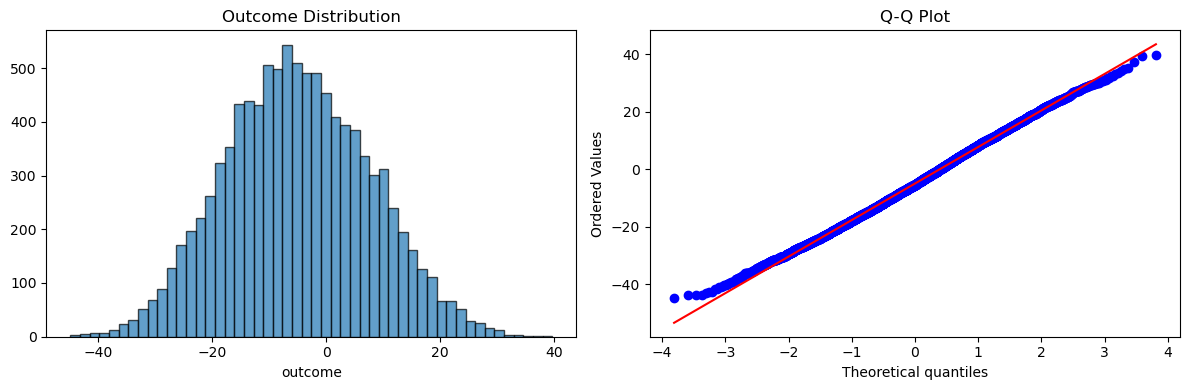

Mean:     -4.979
Std:      12.722
Skewness: 0.083
Kurtosis: -0.260


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(trn['outcome'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Outcome Distribution')
axes[0].set_xlabel('outcome')

from scipy import stats
stats.probplot(trn['outcome'], plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('../reports/figures/outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean:     {trn['outcome'].mean():.3f}")
print(f"Std:      {trn['outcome'].std():.3f}")
print(f"Skewness: {trn['outcome'].skew():.3f}")
print(f"Kurtosis: {trn['outcome'].kurtosis():.3f}")

## 3. Categorical Features

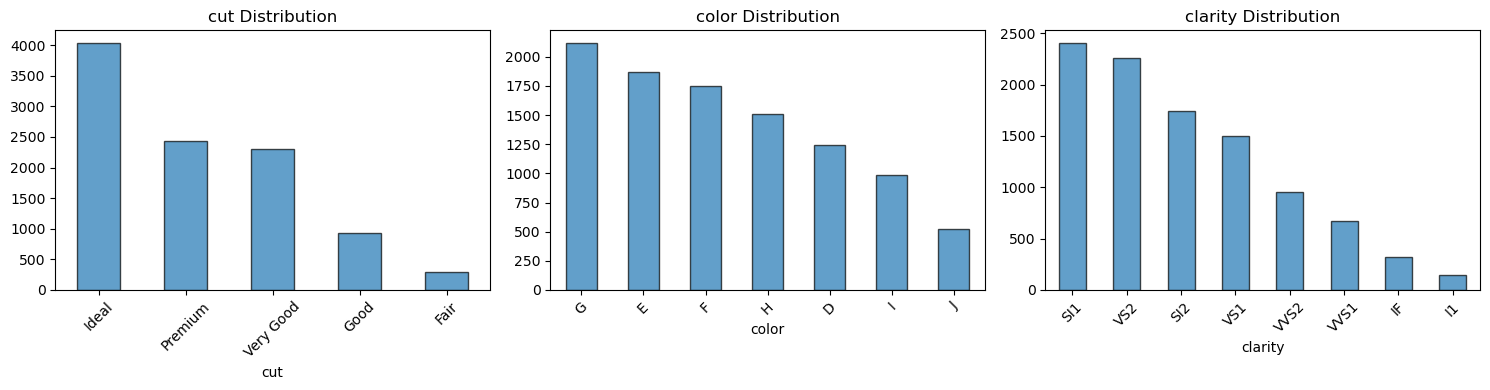

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['cut', 'color', 'clarity']):
    trn[col].value_counts().plot(kind='bar', ax=axes[i], alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

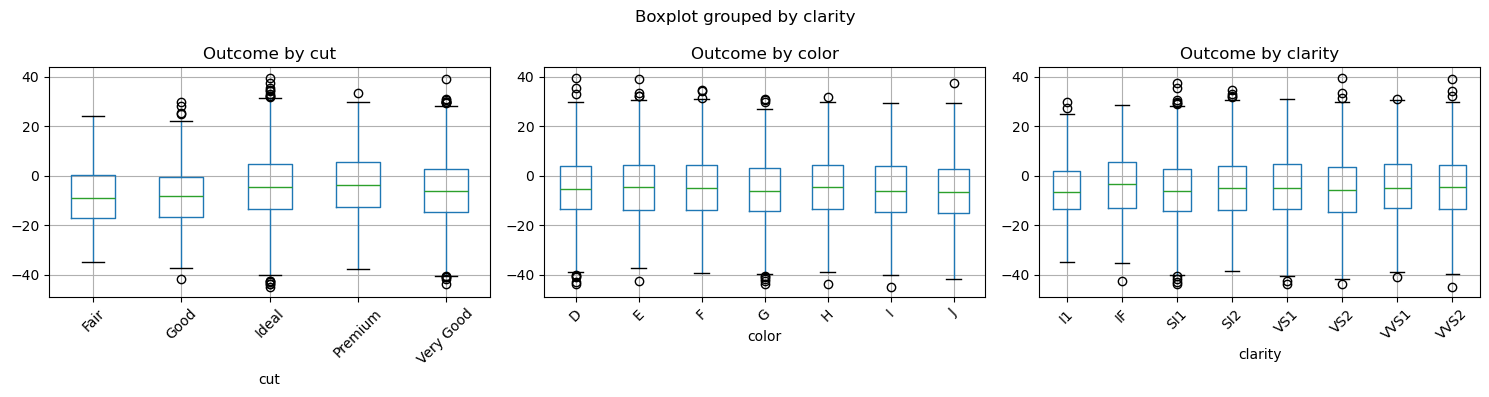

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['cut', 'color', 'clarity']):
    trn.boxplot(column='outcome', by=col, ax=axes[i])
    axes[i].set_title(f'Outcome by {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/outcome_by_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Numeric Feature Correlations

In [9]:
numeric_cols = trn.select_dtypes(include=[np.number]).columns
corrs = trn[numeric_cols].corr()['outcome'].drop('outcome').abs().sort_values(ascending=False)
print("Correlations with outcome (absolute):")
print(corrs)

Correlations with outcome (absolute):
depth    0.411073
b3       0.225407
b1       0.173719
a1       0.149101
a4       0.122441
table    0.114977
z        0.031470
x        0.020354
price    0.016967
y        0.015924
a7       0.012512
b5       0.012370
b10      0.012036
b7       0.009241
a2       0.008760
a8       0.007983
b9       0.007324
a6       0.007238
a9       0.005361
b4       0.003845
a3       0.003126
b8       0.002645
carat    0.002538
a10      0.002492
b2       0.001640
a5       0.000690
b6       0.000079
Name: outcome, dtype: float64


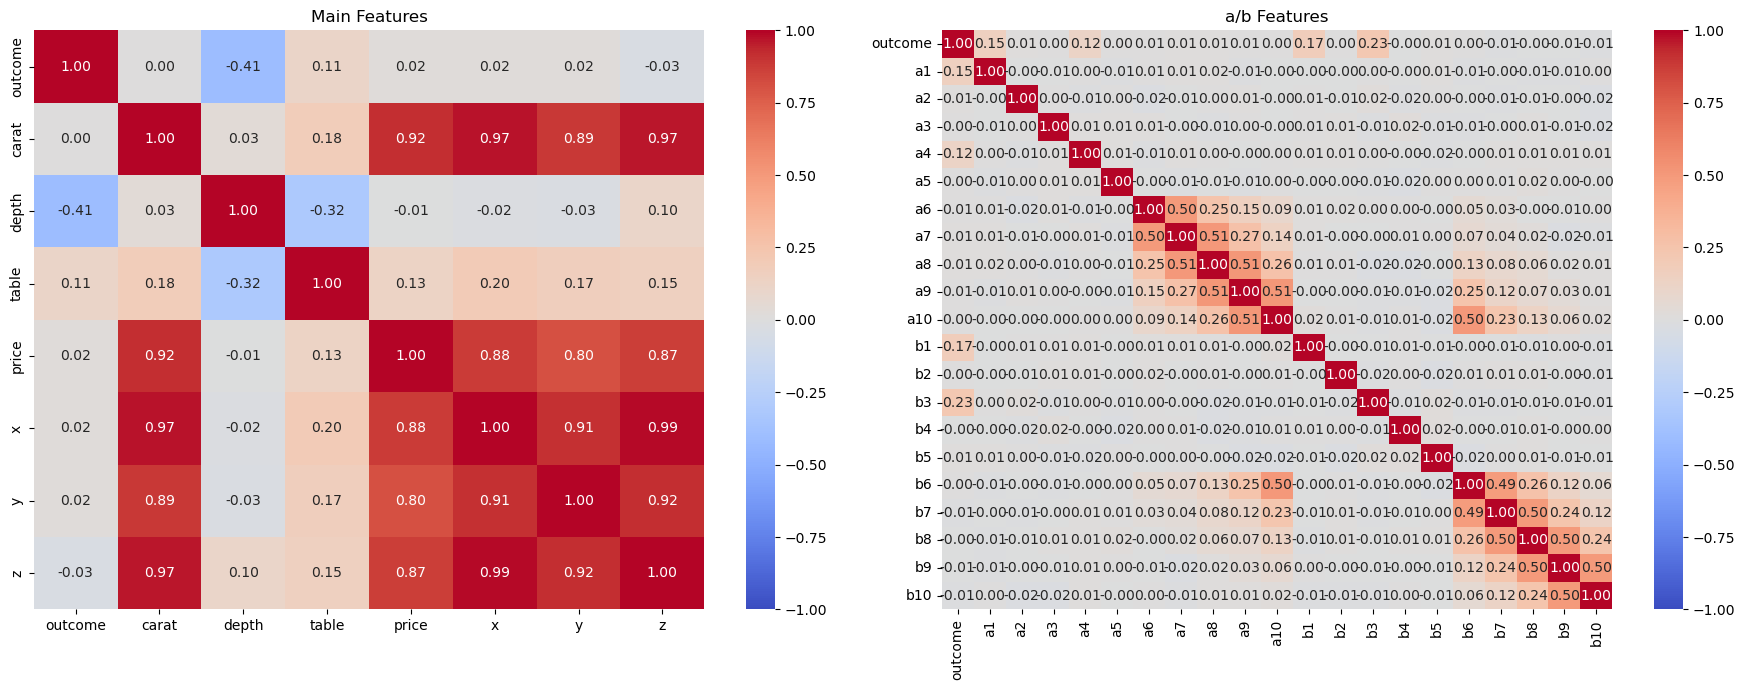

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

main_feats = ['outcome', 'carat', 'depth', 'table', 'price', 'x', 'y', 'z']
sns.heatmap(trn[main_feats].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Main Features')

ab_feats = ['outcome', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a9', 'a10',
            'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9', 'b10']
sns.heatmap(trn[ab_feats].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('a/b Features')

plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Key Feature Scatter Plots

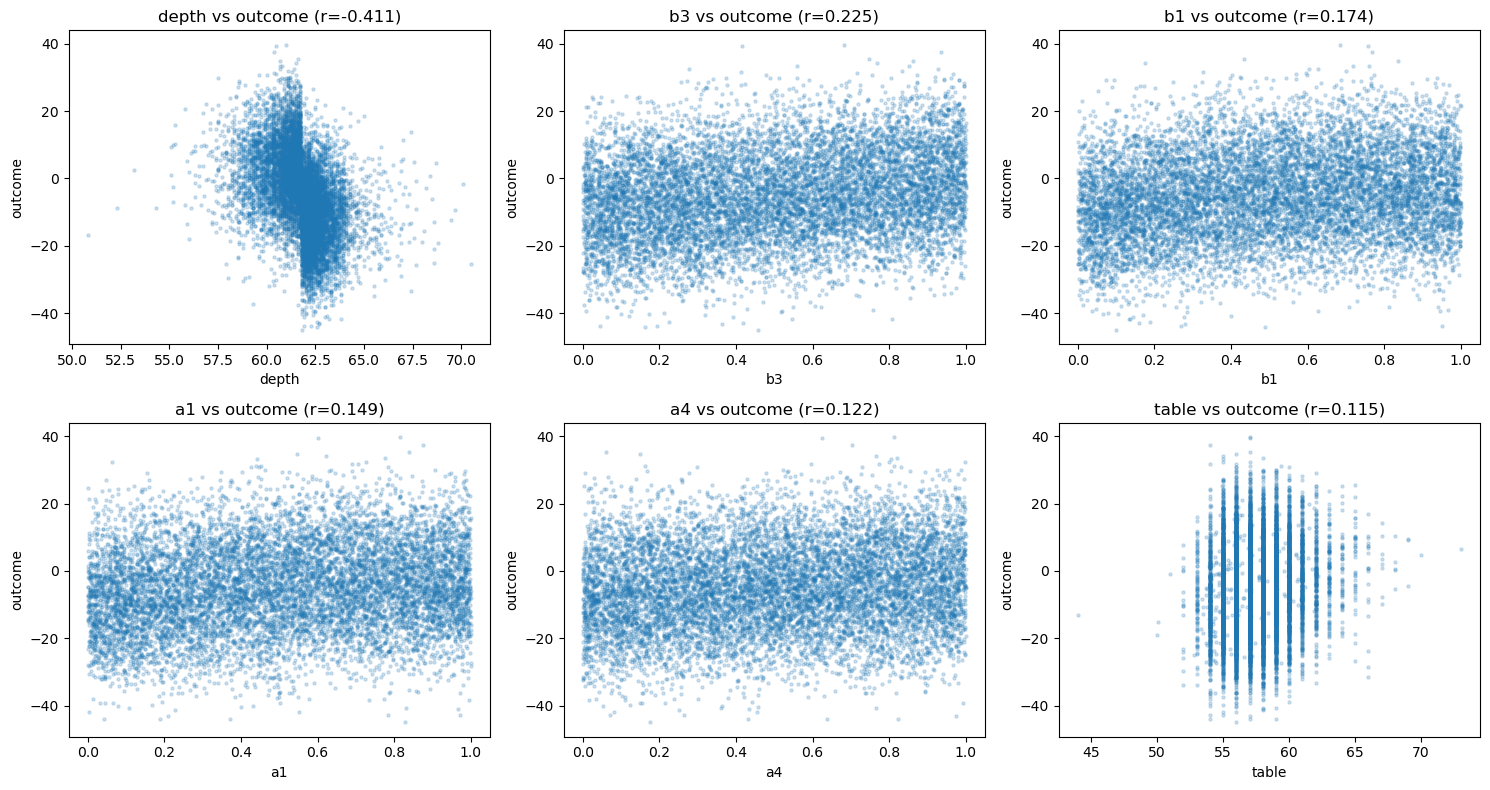

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

pairs = [('depth', 'outcome'), ('b3', 'outcome'), ('b1', 'outcome'),
         ('a1', 'outcome'), ('a4', 'outcome'), ('table', 'outcome')]

for ax, (x, y) in zip(axes.flatten(), pairs):
    ax.scatter(trn[x], trn[y], alpha=0.2, s=5)
    r = trn[x].corr(trn[y])
    ax.set_title(f'{x} vs {y} (r={r:.3f})')
    ax.set_xlabel(x)
    ax.set_ylabel(y)

plt.tight_layout()
plt.savefig('../reports/figures/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Outlier Detection

In [12]:
print("Zero values in dimension columns:")
for col in ['x', 'y', 'z']:
    zeros = (trn[col] == 0).sum()
    print(f"  {col}: {zeros} zeros")

print(f"\nRows with zero x/y/z:")
mask = (trn['x'] == 0) | (trn['y'] == 0) | (trn['z'] == 0)
print(trn.loc[mask, ['carat', 'x', 'y', 'z', 'price', 'outcome']])

Zero values in dimension columns:
  x: 2 zeros
  y: 2 zeros
  z: 4 zeros

Rows with zero x/y/z:
      carat     x     y    z  price    outcome
2634   1.00  6.55  6.48  0.0   3142  16.558572
2722   0.71  0.00  0.00  0.0   2130  -7.873141
4729   1.15  6.88  6.83  0.0   5564   8.877149
8336   2.25  0.00  0.00  0.0  18034   5.281700


## 7. a/b Feature Analysis

Number of a/b features: 20
Mean of means: 0.2460
Mean of stds:  0.6454


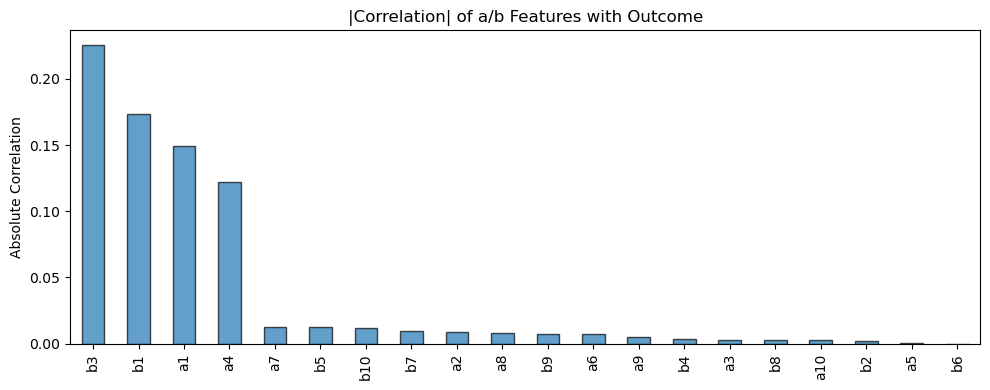

In [13]:
ab_feats = [c for c in trn.columns if (c.startswith('a') and c[1:].isdigit()) or (c.startswith('b') and c[1:].isdigit())]
print(f"Number of a/b features: {len(ab_feats)}")
print(f"Mean of means: {trn[ab_feats].mean().mean():.4f}")
print(f"Mean of stds:  {trn[ab_feats].std().mean():.4f}")

ab_corrs = trn[ab_feats].corrwith(trn['outcome']).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ab_corrs.plot(kind='bar', ax=ax, alpha=0.7, edgecolor='black')
ax.set_title('|Correlation| of a/b Features with Outcome')
ax.set_ylabel('Absolute Correlation')
plt.tight_layout()
plt.savefig('../reports/figures/ab_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

- **No missing values** in the dataset
- **4 rows** with zero x/y/z values (measurement errors to be imputed)
- **depth** is the strongest predictor (r=0.41), followed by b3 (r=0.23) and b1 (r=0.17)
- **outcome** is approximately normally distributed (skew=0.08)
- **carat, price, x, y, z** have near-zero correlation with outcome
- **20 a/b features** resemble standard normal noise, but b3, b1, a1, a4 show meaningful correlation with outcome
- Categorical features (cut, color, clarity) have natural ordinal ordering